# IT3091 - Member 3 - IT24101090 - JAYAKODY N.D


In [1]:
# Clone the latest project from GitHub
!git clone https://github.com/DTD-Wijesinghe/IT3091---Machine-Learning-Assignment.git
%cd /content/IT3091---Machine-Learning-Assignment

Cloning into 'IT3091---Machine-Learning-Assignment'...
remote: Enumerating objects: 122, done.
remote: Counting objects: 100% (122/122), done.
remote: Compressing objects: 100% (107/107), done.
remote: Total 122 (delta 44), reused 28 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (122/122), 7.84 MiB | 4.11 MiB/s, done.
Resolving deltas: 100% (44/44), done.
/content/IT3091---Machine-Learning-Assignment


## Member 3 - Price data, EDA and preprocessing

In [2]:
!pip -q install openpyxl joblib

import os
import re
import json
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

REPO_PATH = Path("/content/IT3091---Machine-Learning-Assignment")
RAW_PATH = REPO_PATH / "Raw Datasets"
PREPROCESSED_PATH = REPO_PATH / "Preprocessed Datasets"

PREPROCESSED_PATH.mkdir(parents=True, exist_ok=True)

print("Raw data:", RAW_PATH)
print("Preprocessed data:", PREPROCESSED_PATH)

Raw data: /content/IT3091---Machine-Learning-Assignment/Raw Datasets
Preprocessed data: /content/IT3091---Machine-Learning-Assignment/Preprocessed Datasets


In [3]:
PRODUCTION_PREP = PREPROCESSED_PATH / "01_production_preprocessed.csv"
WEATHER_PREP = PREPROCESSED_PATH / "02_weather_preprocessed.csv"

price_matches = list(RAW_PATH.glob("*Weekly*Average*Retail*Prices*.xlsx"))
if not price_matches:
    price_matches = list(RAW_PATH.glob("*Weekly*Prices*.xlsx"))

if not price_matches:
    raise FileNotFoundError("Weekly vegetable price workbook was not found in Raw Datasets.")

PRICE_FILE = price_matches[0]

if not PRODUCTION_PREP.exists() or not WEATHER_PREP.exists():
    raise FileNotFoundError(
        "Member 1 and Member 2 preprocessed files are missing. "
        "Make sure their work was pushed to GitHub first."
    )

prod = pd.read_csv(PRODUCTION_PREP)
weather_season = pd.read_csv(WEATHER_PREP)

print("Production rows:", len(prod))
print("Weather rows:", len(weather_season))
print("Price file:", PRICE_FILE.name)

Production rows: 699
Weather rows: 24
Price file: Weekly Average Retail Prices of Vegi - 2012 to 2025.xlsx


In [4]:
preview = pd.read_excel(PRICE_FILE, header=None, nrows=15)

header_row = None

for i, row in preview.iterrows():
    values = [str(v).strip().lower() for v in row.values]

    if "market type" in values:
        header_row = i
        break

if header_row is None:
    raise ValueError("Could not find the Market Type header.")

price_raw = pd.read_excel(PRICE_FILE, header=header_row)

price_raw.columns = [
    re.sub(r"\s+", " ", str(c)).strip()
    for c in price_raw.columns
]

price_raw = price_raw.loc[
    :,
    ~price_raw.columns.astype(str).str.startswith("Unnamed")
]

print("Price shape:", price_raw.shape)
display(price_raw.head())

Price shape: (730, 55)


,Year,Market Type,Commodity,W1,W2,W3,W4,W5,W6,W7,W8,W9,W10,W11,W12,W13,W14,W15,W16,W17,W18,W19,W20,W21,W22,W23,W24,W25,W26,W27,W28,W29,W30,W31,W32,W33,W34,W35,W36,W37,W38,W39,W40,W41,W42,W43,W44,W45,W46,W47,W48,W49,W50,W51,W52
0,2012,Wholesale,GREEN BEANS,90.00,64.0,50.0,66.00,54.00,41.36,50.45,63.75,42.50,47.50,49.09,NaN,44.0,27.0,54.0,68.0,93.0,112.0,80.00,76.0,60.91,70.46,121.67,126.00,124.0,137.00,95.00,66.00,64.54,69.09,75.00,81.36,63.00,78.0,73.63,75.00,70.00,86.0,87.00,100.91,124.0,114.0,131.00,158.75,208.89,190.00,155.00,145.71,118.75,45.00,53.75,42.22
1,2012,Wholesale,CARROT,103.64,70.5,65.0,62.73,53.89,49.54,44.50,46.25,35.50,35.50,35.91,NaN,41.0,36.5,31.0,42.0,27.5,29.0,42.00,44.0,71.36,61.36,65.83,131.67,116.0,85.56,104.17,86.00,76.37,85.83,114.54,111.82,83.63,83.0,80.67,85.50,71.82,64.0,73.50,78.00,74.0,79.0,91.11,133.75,155.56,167.50,178.75,188.75,161.25,143.75,145.87,113.75
2,2012,Wholesale,LEEKS,49.00,51.0,47.5,46.50,53.50,48.50,48.60,48.34,48.50,48.50,51.82,NaN,52.5,55.0,52.5,76.0,53.0,74.0,108.89,120.0,127.00,97.73,111.67,115.00,116.0,108.89,113.34,88.00,68.18,82.92,96.36,82.00,59.00,67.0,66.00,64.17,56.82,55.0,51.00,55.00,56.0,58.5,43.89,56.25,39.38,55.63,56.25,55.00,66.25,65.00,88.75,66.25
3,2012,Wholesale,BEETROOT,84.33,83.0,73.0,91.25,62.50,56.11,49.55,42.50,36.00,33.80,42.00,NaN,37.5,41.0,40.0,42.0,46.5,76.0,79.00,101.0,110.00,91.25,104.17,88.33,85.0,97.73,114.54,86.00,79.09,68.64,71.67,74.17,51.00,66.0,64.54,63.64,57.00,60.5,60.00,63.33,56.0,56.0,51.11,68.00,73.75,89.17,75.00,88.75,87.00,82.50,68.75,89.00
4,2012,Wholesale,KNOL-KHOL,NaN,NaN,60.0,58.00,56.67,45.00,50.00,37.27,38.57,38.57,38.57,NaN,37.0,33.5,33.0,33.0,39.0,40.0,41.00,54.5,64.00,55.91,60.00,69.00,64.0,59.00,36.67,28.33,32.50,37.27,36.82,37.27,34.50,27.0,22.00,21.37,20.87,24.5,35.63,42.22,44.0,42.5,45.00,63.75,65.00,90.00,92.50,80.00,78.87,88.75,85.00,81.43


In [5]:
price = price_raw[
    price_raw["Market Type"].astype(str).str.strip().str.lower().eq("wholesale")
].copy()

price["Year"] = pd.to_numeric(price["Year"], errors="coerce")
price = price.dropna(subset=["Year", "Commodity"]).copy()
price["Year"] = price["Year"].astype(int)

week_cols = [
    c for c in price.columns
    if re.fullmatch(r"W\d+", str(c).strip(), flags=re.I)
]

price_long = price.melt(
    id_vars=["Year", "Market Type", "Commodity"],
    value_vars=week_cols,
    var_name="Week",
    value_name="WholesalePrice_RsKg"
)

price_long["WeekNum"] = pd.to_numeric(
    price_long["Week"].astype(str).str.extract(r"(\d+)")[0],
    errors="coerce"
)

price_long["WholesalePrice_RsKg"] = pd.to_numeric(
    price_long["WholesalePrice_RsKg"],
    errors="coerce"
)

price_long = price_long.dropna(
    subset=["WeekNum", "WholesalePrice_RsKg"]
).copy()

price_long["WeekNum"] = price_long["WeekNum"].astype(int)

iso = (
    price_long["Year"].astype(str)
    + "-W"
    + price_long["WeekNum"].astype(str).str.zfill(2)
    + "-1"
)

price_long["WeekDate"] = pd.to_datetime(
    iso,
    format="%G-W%V-%u",
    errors="coerce"
)

price_long = price_long.dropna(subset=["WeekDate"]).copy()
price_long["MonthDate"] = (
    price_long["WeekDate"].dt.to_period("M").dt.to_timestamp()
)

print("Weekly rows:", len(price_long))

Weekly rows: 15598


In [6]:
def norm_text(x):
    x = str(x).upper().strip()
    x = re.sub(r"[^A-Z0-9]+", " ", x)
    return re.sub(r"\s+", " ", x).strip()

PRICE_TO_PRODUCTION = {
    "GREEN BEANS": "Beans",
    "CARROT": "Carrot",
    "LEEKS": "Leeks",
    "BEETROOT": "Beetroot",
    "KNOL KHOL": "Knolkhol",
    "RADDISH": "Raddish",
    "CABBAGE": "Cabbage",
    "TOMATOES": "Tomatoes",
    "BRINJALS": "Brinjals",
    "CAPSICUM": "Capsicum",
    "ASH PLANTAINS": "Ash Plantain",
    "BITTER GOURD": "Bitter Gourd",
    "CUCUMBER": "Cucumber",
    "DRUMSTIC": "Drumstics",
    "LADIES FINGERS": "Bandakka",
    "LONG BEANS": "Long Bean",
    "LUFFA": "Luffa",
    "SNAKE GOURD": "Snake Gourd"
}

price_long["CommodityKey"] = price_long["Commodity"].map(norm_text)
price_long["Crop"] = price_long["CommodityKey"].map(PRICE_TO_PRODUCTION)
price_long = price_long.dropna(subset=["Crop"]).copy()

print("Mapped crops:", price_long["Crop"].nunique())

Mapped crops: 18


In [7]:
monthly = (
    price_long.groupby(
        ["Crop", "MonthDate"],
        as_index=False
    )["WholesalePrice_RsKg"]
    .mean()
    .sort_values(["Crop", "MonthDate"])
)

parts = []

for crop, g in monthly.groupby("Crop"):
    g = g.set_index("MonthDate").sort_index()

    full_idx = pd.date_range(
        g.index.min(),
        g.index.max(),
        freq="MS"
    )

    g = g.reindex(full_idx)
    g.index.name = "MonthDate"
    g["Crop"] = crop
    g["PrevMonthWholesalePrice_RsKg"] = g["WholesalePrice_RsKg"].shift(1)
    g["NextMonthWholesalePrice_RsKg"] = g["WholesalePrice_RsKg"].shift(-1)

    parts.append(g.reset_index())

price_monthly = pd.concat(parts, ignore_index=True)

price_output = PREPROCESSED_PATH / "03_price_preprocessed.csv"
price_monthly.to_csv(price_output, index=False)

print("Saved:", price_output)
display(price_monthly.head())

Saved: /content/IT3091---Machine-Learning-Assignment/Preprocessed Datasets/03_price_preprocessed.csv


,MonthDate,Crop,WholesalePrice_RsKg,PrevMonthWholesalePrice_RsKg,NextMonthWholesalePrice_RsKg
0,2012-01-01,Ash Plantain,41.372000,NaN,33.335000
1,2012-02-01,Ash Plantain,33.335000,41.372000,24.166667
2,2012-03-01,Ash Plantain,24.166667,33.335000,21.180000
3,2012-04-01,Ash Plantain,21.180000,24.166667,17.680000
4,2012-05-01,Ash Plantain,17.680000,21.180000,24.472500


In [8]:
SEASON_ANCHOR_MONTH = {
    "Yala": 4,
    "Maha": 9
}

prod["AnchorMonth"] = prod["Season"].map(SEASON_ANCHOR_MONTH)

prod["AnchorDate"] = pd.to_datetime({
    "year": prod["Year"],
    "month": prod["AnchorMonth"],
    "day": 1
})

model_data = prod.merge(
    weather_season,
    on=["Year", "Season"],
    how="left",
    validate="many_to_one"
)

price_for_merge = price_monthly[
    [
        "Crop",
        "MonthDate",
        "PrevMonthWholesalePrice_RsKg",
        "NextMonthWholesalePrice_RsKg"
    ]
].copy()

model_data = model_data.merge(
    price_for_merge,
    left_on=["Crop", "AnchorDate"],
    right_on=["Crop", "MonthDate"],
    how="left",
    validate="many_to_one"
)

model_data = model_data[
    model_data["Year"].between(2012, 2023)
].copy()

model_data = model_data.dropna(
    subset=[
        "Yield_t_ha",
        "NextMonthWholesalePrice_RsKg"
    ]
).copy()

model_data = model_data.drop(
    columns=["MonthDate"],
    errors="ignore"
)

print("Final modelling shape:", model_data.shape)
print("Year range:", model_data["Year"].min(), "-", model_data["Year"].max())
display(model_data.head())

Final modelling shape: (360, 19)
Year range: 2012 - 2023


,District,Season,CropCategory,Crop,Year,Extent,Production,Yield_t_ha,Yield_IQR_Flag,AnchorMonth,AnchorDate,SeasonMeanTemp_C,SeasonTotalPrecip_mm,SeasonMeanWind_kmh,SeasonMeanSolar_MJm2,SeasonTotalET0_mm,WeatherDays,PrevMonthWholesalePrice_RsKg,NextMonthWholesalePrice_RsKg
0,National Total,Yala,Low Country Vegetable,Luffa,2012,1861.0,17053.0,9.163353,False,4,2012-04-01,26.729557,461.511111,19.387098,20.372622,722.928519,153.0,34.223333,53.8075
1,National Total,Maha,Low Country Vegetable,Luffa,2012,2840.0,25733.0,9.060915,False,9,2012-09-01,25.019881,1541.337037,14.031516,17.581104,790.763333,212.0,35.477500,59.0260
2,National Total,Yala,Low Country Vegetable,Luffa,2013,1985.0,17801.0,8.967758,False,4,2013-04-01,26.401065,603.770370,18.785476,19.653951,672.985926,153.0,48.970000,49.2650
3,National Total,Maha,Low Country Vegetable,Luffa,2013,3005.0,28598.0,9.516805,False,9,2013-09-01,25.089745,818.574074,15.617051,18.621454,854.841111,212.0,49.625000,41.2200
4,National Total,Yala,Low Country Vegetable,Luffa,2014,1881.0,16066.0,8.541201,False,4,2014-04-01,26.723844,600.807407,18.497434,20.152554,698.109630,153.0,51.710000,87.4350


## EDA

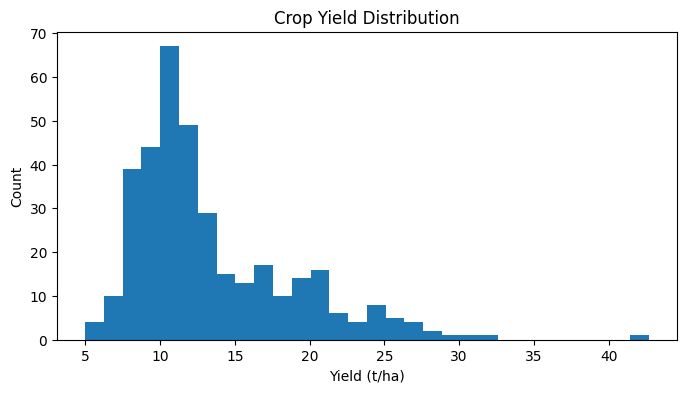

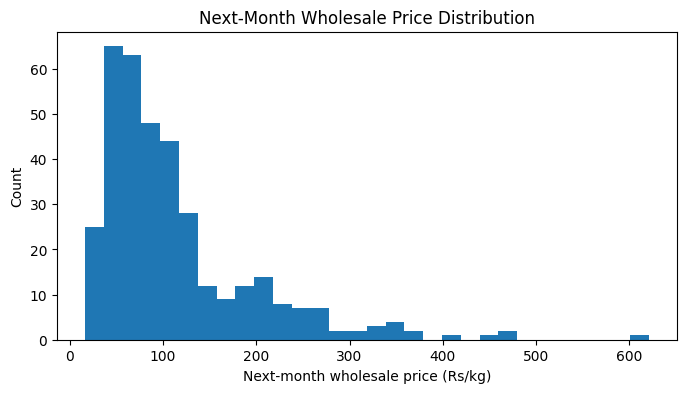

In [9]:
plt.figure(figsize=(8, 4))
plt.hist(model_data["Yield_t_ha"].dropna(), bins=30)
plt.xlabel("Yield (t/ha)")
plt.ylabel("Count")
plt.title("Crop Yield Distribution")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(model_data["NextMonthWholesalePrice_RsKg"].dropna(), bins=30)
plt.xlabel("Next-month wholesale price (Rs/kg)")
plt.ylabel("Count")
plt.title("Next-Month Wholesale Price Distribution")
plt.show()

In [10]:
yield_trend = (
    model_data.groupby("Year", as_index=False)["Yield_t_ha"].mean()
)

price_trend = (
    model_data.groupby(
        "Year",
        as_index=False
    )["NextMonthWholesalePrice_RsKg"].mean()
)

display(
    model_data.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing")
)

print("Duplicate rows:", model_data.duplicated().sum())
print(
    "Duplicate Crop+Season+Year:",
    model_data.duplicated(["Crop", "Season", "Year"]).sum()
)

,missing
PrevMonthWholesalePrice_RsKg,1
Season,0
District,0
CropCategory,0
Crop,0
Extent,0
Year,0
Yield_t_ha,0
Yield_IQR_Flag,0
AnchorMonth,0


Duplicate rows: 0
Duplicate Crop+Season+Year: 0


In [11]:
final_dataset = PREPROCESSED_PATH / "03_final_modelling_dataset.csv"
model_data.to_csv(final_dataset, index=False)

print("Saved:", final_dataset)
print("Rows:", len(model_data))

Saved: /content/IT3091---Machine-Learning-Assignment/Preprocessed Datasets/03_final_modelling_dataset.csv
Rows: 360


In [ ]:
from getpass import getpass
from google.colab import _message
import subprocess

MEMBER_NAME = 'JAYAKODY N.D'
NOTEBOOK_NAME = '03_IT24101090_JAYAKODY_ND_Price_EDA_Preprocessing.ipynb'
FILES_TO_ADD = ['Preprocessed Datasets/03_price_preprocessed.csv', 'Preprocessed Datasets/03_final_modelling_dataset.csv']

# Save the current Colab notebook inside the cloned repository
current_notebook = _message.blocking_request("get_ipynb", request="", timeout_sec=10)
notebook_path = REPO_PATH / NOTEBOOK_NAME

with open(notebook_path, "w", encoding="utf-8") as f:
    json.dump(current_notebook["ipynb"], f, ensure_ascii=False, indent=1)

print("Saved notebook:", notebook_path.name)

# Git identity
github_email = input("GitHub email: ").strip()
github_username = input("GitHub username: ").strip()
github_token = getpass("GitHub Personal Access Token: ")

subprocess.run(["git", "config", "user.name", MEMBER_NAME], cwd=REPO_PATH, check=True)
subprocess.run(["git", "config", "user.email", github_email], cwd=REPO_PATH, check=True)

# Add notebook and this member's output files
for item in [NOTEBOOK_NAME] + FILES_TO_ADD:
    subprocess.run(["git", "add", item], cwd=REPO_PATH, check=True)

status = subprocess.run(
    ["git", "status", "--short"],
    cwd=REPO_PATH,
    text=True,
    capture_output=True,
    check=True
)
print(status.stdout)

# Commit only when there is something new
if status.stdout.strip():
    subprocess.run(
        ["git", "commit", "-m", 'Member 3: Add price preprocessing EDA and final modelling dataset'],
        cwd=REPO_PATH,
        check=True
    )
else:
    print("Nothing new to commit.")

# Secure GitHub authentication for this push
askpass = Path("/tmp/git_askpass.sh")
askpass.write_text(
    '#!/bin/sh\n'
    'case "$1" in\n'
    '  *Username*) echo "$GITHUB_USERNAME" ;;\n'
    '  *Password*) echo "$GITHUB_TOKEN" ;;\n'
    'esac\n'
)
askpass.chmod(0o700)

env = os.environ.copy()
env["GITHUB_USERNAME"] = github_username
env["GITHUB_TOKEN"] = github_token
env["GIT_ASKPASS"] = str(askpass)

result = subprocess.run(
    ["git", "push", "origin", "main"],
    cwd=REPO_PATH,
    env=env,
    text=True,
    capture_output=True
)

print(result.stdout)
print(result.stderr)

if result.returncode != 0:
    raise RuntimeError("Push failed. Check the GitHub username, token and repository permission.")

print("Push completed.")